In [2]:
import pandas as pd

# Load the dataset
Device_compromise_table = pd.read_excel("../device_compromise_dataset.xlsx", index_col=False)

# Fill NaNs with empty string first to avoid issues with .str operations
Device_compromise_table['tactics'] = Device_compromise_table['tactics'].fillna('')

# Split the comma-separated strings into lists
Device_compromise_table['tactics'] = Device_compromise_table['tactics'].str.split(',')

# Remove leading/trailing spaces safely
Device_compromise_table['tactics'] = Device_compromise_table['tactics'].apply(
    lambda x: [i.strip() for i in x if i.strip()]
)

# Explode the column
Device_compromise_table = Device_compromise_table.explode('tactics')

pd.set_option('display.max_columns', None)  # Show all columns
# Display result
Device_compromise_table


,CVE ID,Description,attackVector,baseScore,baseSeverity,attackComplexity,privilegesRequired,userInteraction,confidentialityImpact,availabilityImpact,integrityImpact,exploitabilityScore,capec_Name,capec_Mitre_Techniques,capec_Abstraction,capec_Status,capec_Description,capec_Extended_Description,capec_Likelihood_Of_Attack,capec_Typical_Severity,capec_Execution_Flow,capec_Prerequisites,capec_Skills_Required,capec_Resources_Required,capec_Consequences,capec_Mitigations,capec_Example_Instances,capec_Related_Weaknesses,capec_Taxonomy_Mappings,cwe_Name,cwe_Abstraction,cwe_Structure,cwe_Status,cwe_Description,cwe_Extended_Description,cwe_Related_Weaknesses,cwe_Weakness_Ordinality,cwe_Language_Name,cwe_Technology_Class,cwe_Alternate_Terms,cwe_Alternate_Terms_With_Descriptions,cwe_Background_Details,cwe_Modes_Of_Introduction,cwe_Likelihood_Of_Exploit,cwe_Common_Consequences,cwe_Detection_Methods,cwe_Potential_Mitigations,cwe_Demonstrative_Examples,cwe_Observed_Examples,technique_name,tech_description,subtechnique_name,tactics,detection,platforms,data sources,defenses bypassed,contributors,permissions required,supports remote,system requirements,impact type,effective permissions
0,CVE-2014-5433,An unauthenticated remote attacker may be able...,NETWORK,9.8,CRITICAL,LOW,NONE,NONE,HIGH,HIGH,HIGH,3.9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CVE-2014-5433,An unauthenticated remote attacker may be able...,NETWORK,9.8,CRITICAL,LOW,NONE,NONE,HIGH,HIGH,HIGH,3.9,Retrieve Embedded Sensitive Data,1005 - Data from Local System,Detailed,Draft,An attacker examines a target system to find s...,NaN,High,Very High,Step 1: Explore - [Identify Target] Attacker i...,In order to feasibly execute this type of atta...,Medium: The attacker must possess knowledge of...,The attacker must possess access to the system...,Scope: Confidentiality | Impact: Read Data || ...,NaN,Using a tool such as 'strings' or similar to p...,"CWE-226, CWE-311, CWE-525, CWE-312, CWE-314, C...",ATTACK: 1005 - Data from Local System || ATTAC...,Cleartext Storage of Sensitive Information,Base,Simple,Draft,The product stores sensitive information in cl...,NaN,"CWE-311 (ChildOf, View: 1000, Ordinal: Primary...",NaN,NaN,"Mobile, Cloud Computing, ICS/OT",NaN,NaN,NaN,Architecture and Design: OMISSION: This weakne...,NaN,Scope: Confidentiality | Impact: Read Applicat...,Method: Automated Static Analysis | Effectiven...,Phase: Implementation | Description: N/A,Intro: The following code excerpt stores a pla...,Reference: CVE-2022-30275 | Description: Remot...,Data from Local System,"Adversaries may search local system sources, s...",NaN,Collection,Monitor processes and command-line arguments f...,"Linux, Network, Windows, macOS","Command: Command Execution, File: File Access,...",NaN,"Austin Clark, @c2defense; William Cain",NaN,0.0,Privileges to access certain files and directo...,NaN,NaN
2,CVE-2014-5433,An unauthenticated remote attacker may be able...,NETWORK,9.8,CRITICAL,LOW,NONE,NONE,HIGH,HIGH,HIGH,3.9,Retrieve Embedded Sensitive Data,1552.004 - Unsecured Credentials,Detailed,Draft,An attacker examines a target system to find s...,NaN,High,Very High,Step 1: Explore - [Identify Target] Attacker i...,In order to feasibly execute this type of atta...,Medium: The attacker must possess knowledge of...,The attacker must possess access to the system...,Scope: Confidentiality | Impact: Read Data || ...,NaN,Using a tool such as 'strings' or similar to p...,"CWE-226, CWE-311, CWE-525, CWE-312, CWE-314, C...",ATTACK: 1005 - Data from Local System || ATTAC...,Cleartext Storage of Sensitive Information,Base,Simple,Draft,The product stores sensitive information in cl...,NaN,"CWE-311 (ChildOf, View: 1000, Ordinal: Primary...",NaN,NaN,"Mobile, Cloud Computing, ICS/OT",NaN,NaN,NaN,Architecture and Design: OMISSION: This weakne...,NaN,Scope: Confid

In [6]:
Device_compromise_table["cwe_Name"].value_counts()

cwe_Name
Incorrect Permission Assignment for Critical Resource    28
Use of Hard-coded Credentials                            25
Improper Authentication                                  18
Cleartext Transmission of Sensitive Information           7
Use of Hard-coded Password                                5
Cleartext Storage of Sensitive Information                2
Operation on a Resource after Expiration or Release       1
DEPRECATED: Authentication Bypass Issues                  1
Name: count, dtype: int64

In [4]:
unique_counts = {
    "Unique CVEs": Device_compromise_table["CVE ID"].nunique(),
    "Unique CWEs": Device_compromise_table["cwe_Name"].nunique(),
    "Unique CAPECs": Device_compromise_table["capec_Name"].nunique(),
    "Unique MITRE Techniques": Device_compromise_table["technique_name"].nunique(),
    "Unique MITRE Subtechniques": Device_compromise_table["subtechnique_name"].nunique(),
    "Unique Tactics": Device_compromise_table["tactics"].nunique()
}

print(unique_counts)



{'Unique CVEs': 10, 'Unique CWEs': 8, 'Unique CAPECs': 29, 'Unique MITRE Techniques': 16, 'Unique MITRE Subtechniques': 12, 'Unique Tactics': 8}


In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import Counter, defaultdict
import networkx as nx
from datetime import datetime
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Load the JSON data
with open('attack_tree_data/attack_tree_structure_20250913_025539_complete.json', 'r') as f:
    data = json.load(f)

print("Data loaded successfully!")
print(f"Total nodes: {len(data['nodes'])}")
print(f"Total paths: {len(data['paths'])}")
print(f"Node types: {list(data['statistics']['node_type_counts'].keys())}")

Data loaded successfully!
Total nodes: 100
Total paths: 27
Node types: ['root', 'tactic', 'cwe', 'subtech', 'gate', 'capec', 'tech']


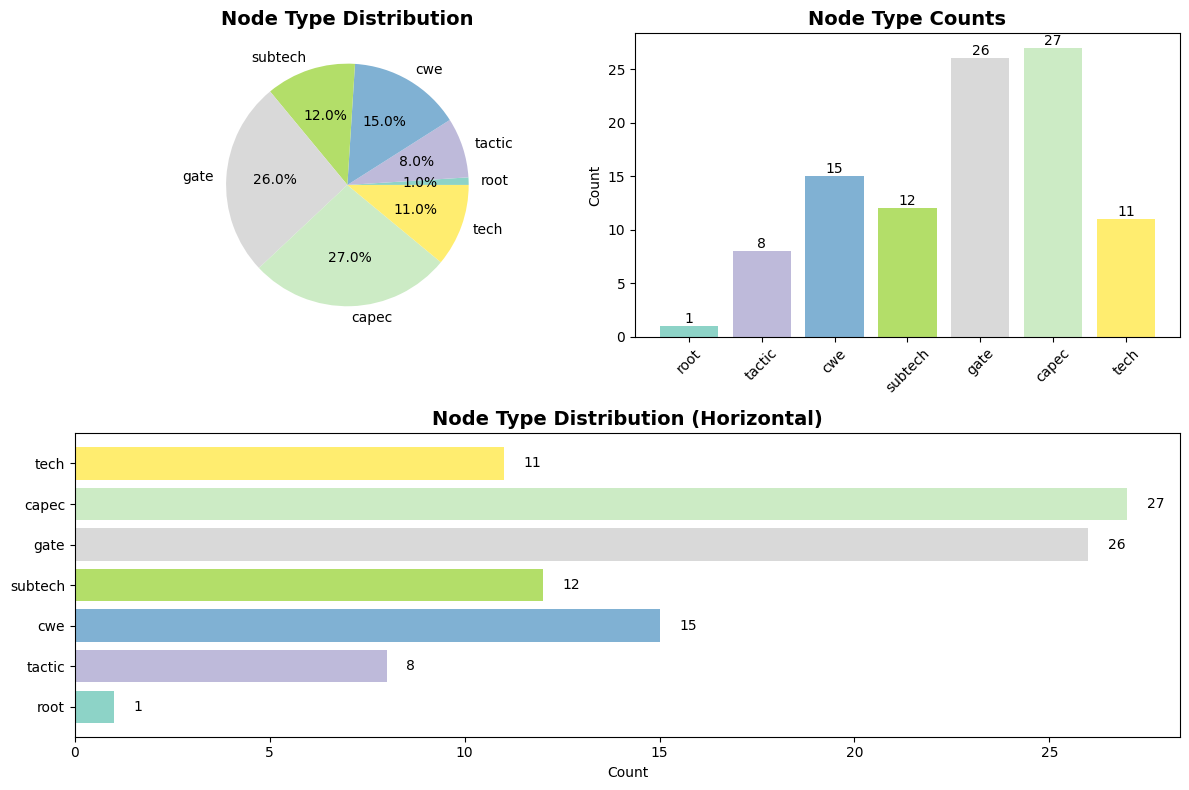

In [ ]:
# Visualization 1: Node Type Distribution
import matplotlib.pyplot as plt
import seaborn as sns

def create_node_type_distribution():
    node_counts = data['statistics']['node_type_counts']
    
    plt.figure(figsize=(12, 8))
    
    # Create pie chart
    plt.subplot(2, 2, 1)
    colors = plt.cm.Set3(np.linspace(0, 1, len(node_counts)))
    plt.pie(node_counts.values(), labels=node_counts.keys(), autopct='%1.1f%%', colors=colors)
    plt.title('Node Type Distribution', fontsize=14, fontweight='bold')
    
    # Create bar chart
    plt.subplot(2, 2, 2)
    bars = plt.bar(node_counts.keys(), node_counts.values(), color=colors)
    plt.title('Node Type Counts', fontsize=14, fontweight='bold')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # Create horizontal bar chart
    plt.subplot(2, 1, 2)
    y_pos = np.arange(len(node_counts))
    plt.barh(y_pos, list(node_counts.values()), color=colors)
    plt.yticks(y_pos, list(node_counts.keys()))
    plt.xlabel('Count')
    plt.title('Node Type Distribution (Horizontal)', fontsize=14, fontweight='bold')
    
    # Add value labels
    for i, v in enumerate(node_counts.values()):
        plt.text(v + 0.5, i, str(v), va='center')
    
    plt.tight_layout()
    plt.savefig('node_type_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()

create_node_type_distribution()

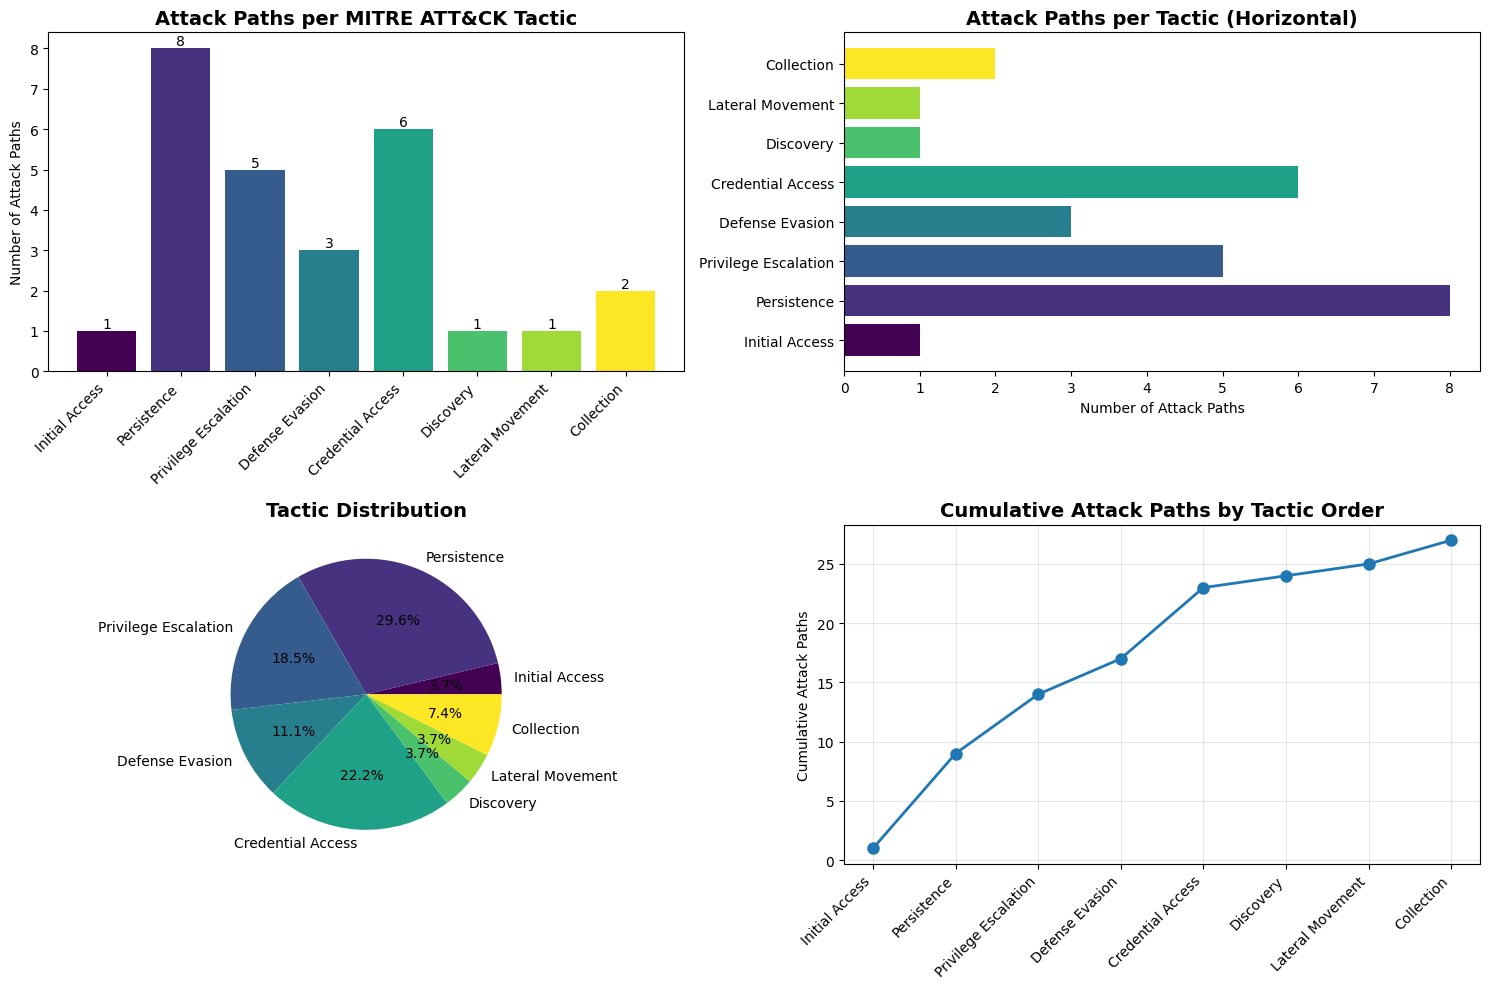

In [ ]:
# Visualization 2: Tactic Analysis
def create_tactic_analysis():
    # Extract tactic information
    tactic_data = []
    for node_id, node in data['nodes'].items():
        if node['node_type'] == 'tactic':
            tactic_data.append({
                'tactic': node['label'],
                'order': node['metadata']['mitre_order']
            })
    
    tactic_df = pd.DataFrame(tactic_data).sort_values('order')
    
    # Count paths per tactic
    path_counts = Counter()
    for path in data['paths'].values():
        path_counts[path['tactic']] += 1
    
    tactic_df['path_count'] = tactic_df['tactic'].map(path_counts)
    
    plt.figure(figsize=(15, 10))
    
    # Tactic order visualization
    plt.subplot(2, 2, 1)
    bars = plt.bar(range(len(tactic_df)), tactic_df['path_count'], 
                   color=plt.cm.viridis(np.linspace(0, 1, len(tactic_df))))
    plt.xticks(range(len(tactic_df)), tactic_df['tactic'], rotation=45, ha='right')
    plt.ylabel('Number of Attack Paths')
    plt.title('Attack Paths per MITRE ATT&CK Tactic', fontsize=14, fontweight='bold')
    
    for i, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # Horizontal version
    plt.subplot(2, 2, 2)
    plt.barh(range(len(tactic_df)), tactic_df['path_count'],
             color=plt.cm.viridis(np.linspace(0, 1, len(tactic_df))))
    plt.yticks(range(len(tactic_df)), tactic_df['tactic'])
    plt.xlabel('Number of Attack Paths')
    plt.title('Attack Paths per Tactic (Horizontal)', fontsize=14, fontweight='bold')
    
    # Pie chart
    plt.subplot(2, 2, 3)
    plt.pie(tactic_df['path_count'], labels=tactic_df['tactic'], autopct='%1.1f%%',
            colors=plt.cm.viridis(np.linspace(0, 1, len(tactic_df))))
    plt.title('Tactic Distribution', fontsize=14, fontweight='bold')
    
    # Cumulative analysis
    plt.subplot(2, 2, 4)
    cumulative = np.cumsum(tactic_df['path_count'])
    plt.plot(range(len(tactic_df)), cumulative, marker='o', linewidth=2, markersize=8)
    plt.xticks(range(len(tactic_df)), tactic_df['tactic'], rotation=45, ha='right')
    plt.ylabel('Cumulative Attack Paths')
    plt.title('Cumulative Attack Paths by Tactic Order', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('tactic_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return tactic_df

tactic_df = create_tactic_analysis()

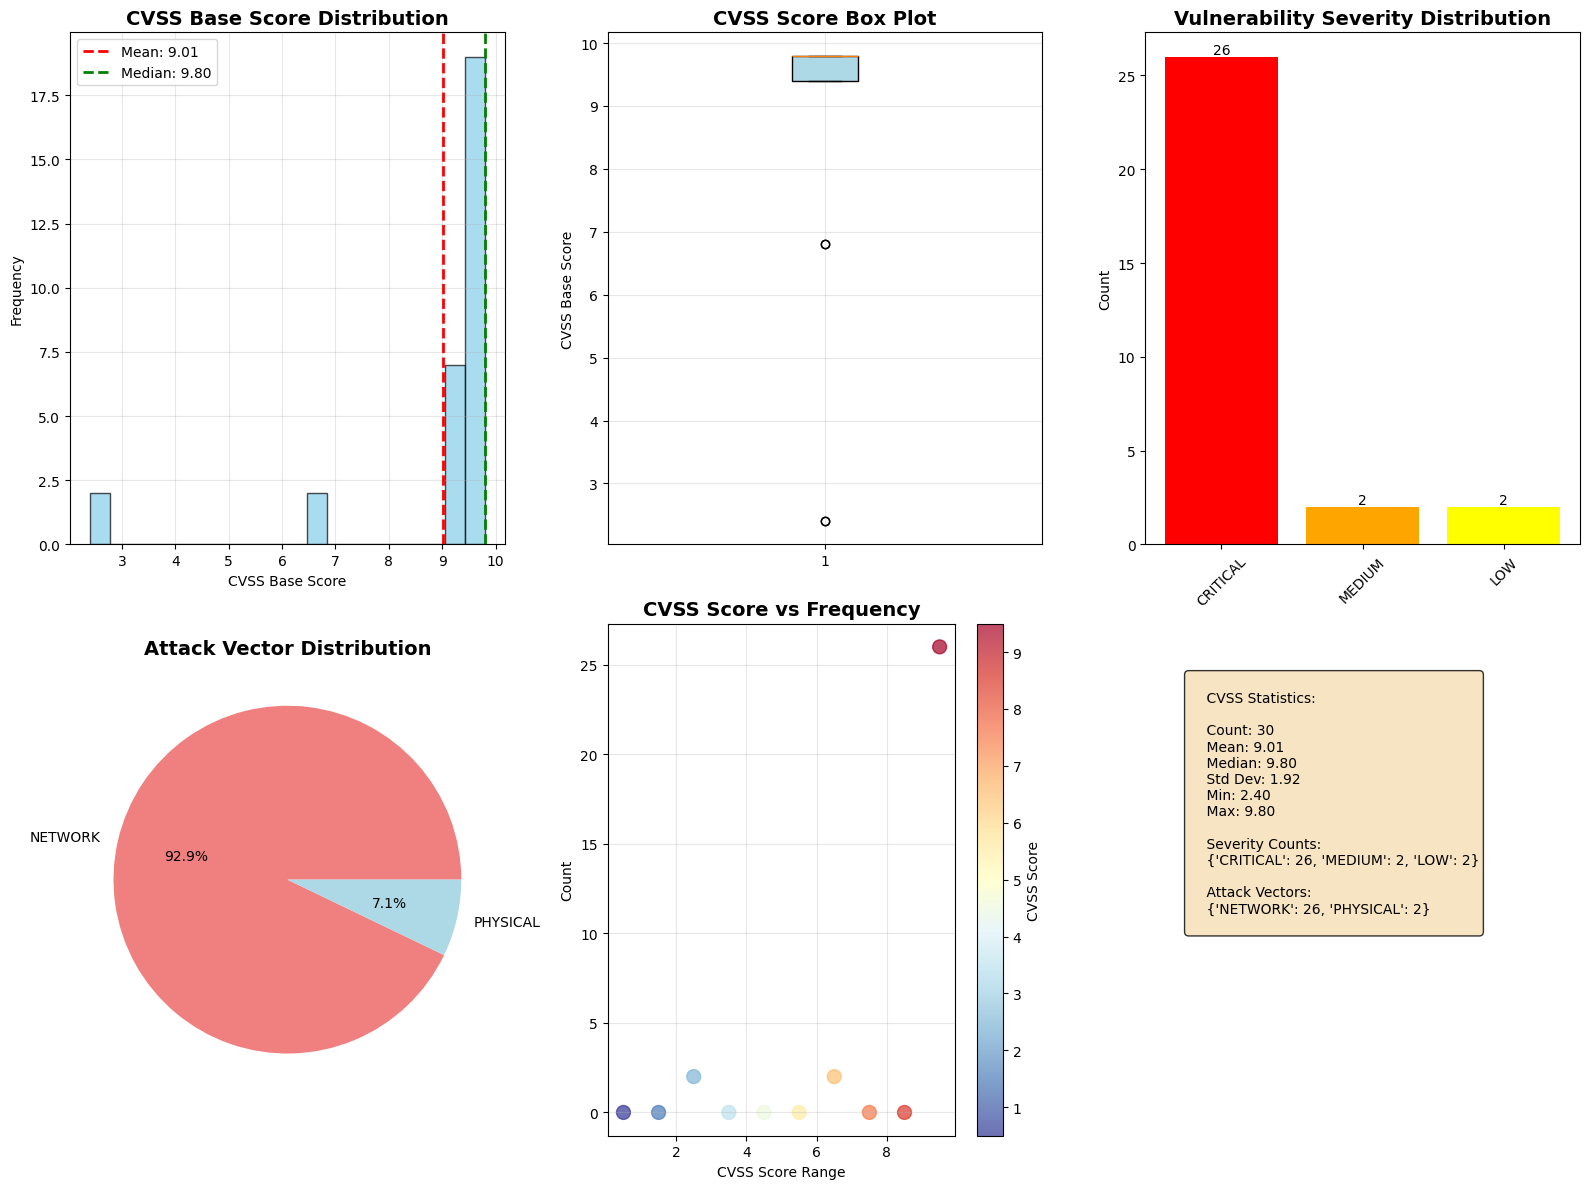

In [ ]:
# Visualization 3: CVSS Score Analysis
def create_cvss_analysis():
    cvss_scores = []
    severities = []
    attack_vectors = []
    
    for node_id, node in data['nodes'].items():
        if 'baseScore' in node['metadata']:
            scores = node['metadata']['baseScore']
            if '|' in str(scores):
                for score in str(scores).split(' | '):
                    try:
                        cvss_scores.append(float(score))
                    except:
                        pass
            else:
                try:
                    cvss_scores.append(float(scores))
                except:
                    pass
        
        if 'baseSeverity' in node['metadata']:
            sev = node['metadata']['baseSeverity']
            if '|' in str(sev):
                severities.extend(str(sev).split(' | '))
            else:
                severities.append(str(sev))
        
        if 'attackVector' in node['metadata']:
            vec = node['metadata']['attackVector']
            if '|' in str(vec):
                attack_vectors.extend(str(vec).split(' | '))
            else:
                attack_vectors.append(str(vec))
    
    plt.figure(figsize=(16, 12))
    
    # CVSS Score Distribution
    plt.subplot(2, 3, 1)
    plt.hist(cvss_scores, bins=20, color='skyblue', alpha=0.7, edgecolor='black')
    plt.axvline(np.mean(cvss_scores), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(cvss_scores):.2f}')
    plt.axvline(np.median(cvss_scores), color='green', linestyle='--', linewidth=2, label=f'Median: {np.median(cvss_scores):.2f}')
    plt.xlabel('CVSS Base Score')
    plt.ylabel('Frequency')
    plt.title('CVSS Base Score Distribution', fontsize=14, fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Box plot
    plt.subplot(2, 3, 2)
    plt.boxplot(cvss_scores, patch_artist=True, boxprops=dict(facecolor='lightblue'))
    plt.ylabel('CVSS Base Score')
    plt.title('CVSS Score Box Plot', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Severity Distribution
    plt.subplot(2, 3, 3)
    severity_counts = Counter(severities)
    colors = ['red', 'orange', 'yellow', 'green'][:len(severity_counts)]
    bars = plt.bar(severity_counts.keys(), severity_counts.values(), color=colors)
    plt.title('Vulnerability Severity Distribution', fontsize=14, fontweight='bold')
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')
    
    # Attack Vector Distribution
    plt.subplot(2, 3, 4)
    vector_counts = Counter(attack_vectors)
    plt.pie(vector_counts.values(), labels=vector_counts.keys(), autopct='%1.1f%%',
            colors=['lightcoral', 'lightblue', 'lightgreen', 'lightyellow'])
    plt.title('Attack Vector Distribution', fontsize=14, fontweight='bold')
    
    # CVSS vs Frequency scatter
    plt.subplot(2, 3, 5)
    score_bins = np.arange(0, 11, 1)
    hist_counts, _ = np.histogram(cvss_scores, bins=score_bins)
    bin_centers = (score_bins[:-1] + score_bins[1:]) / 2
    plt.scatter(bin_centers, hist_counts, s=100, alpha=0.7, c=bin_centers, cmap='RdYlBu_r')
    plt.xlabel('CVSS Score Range')
    plt.ylabel('Count')
    plt.title('CVSS Score vs Frequency', fontsize=14, fontweight='bold')
    plt.colorbar(label='CVSS Score')
    plt.grid(True, alpha=0.3)
    
    # Statistics text
    plt.subplot(2, 3, 6)
    plt.axis('off')
    stats_text = f"""
    CVSS Statistics:
    
    Count: {len(cvss_scores)}
    Mean: {np.mean(cvss_scores):.2f}
    Median: {np.median(cvss_scores):.2f}
    Std Dev: {np.std(cvss_scores):.2f}
    Min: {np.min(cvss_scores):.2f}
    Max: {np.max(cvss_scores):.2f}
    
    Severity Counts:
    {dict(Counter(severities))}
    
    Attack Vectors:
    {dict(Counter(attack_vectors))}
    """
    plt.text(0.1, 0.9, stats_text, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('cvss_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return cvss_scores, severities, attack_vectors

cvss_scores, severities, attack_vectors = create_cvss_analysis()

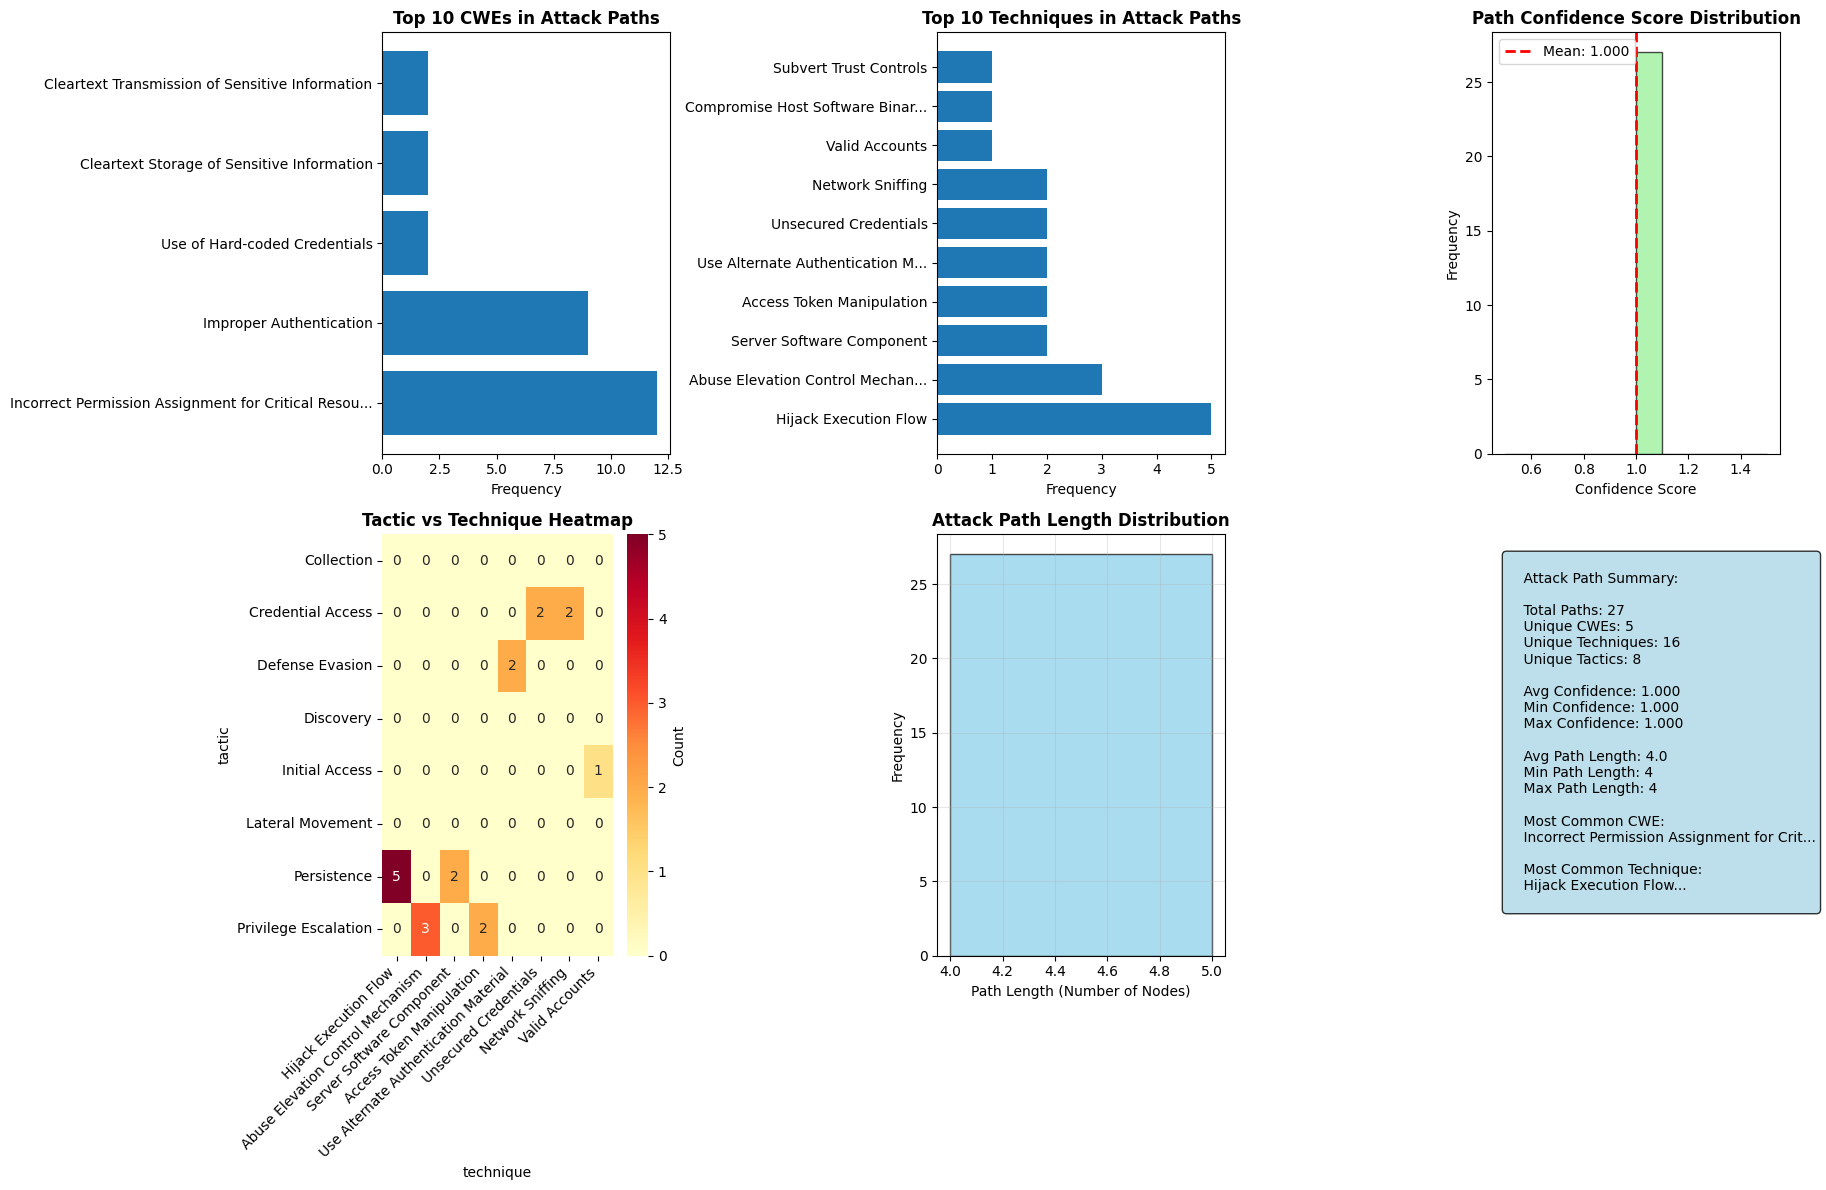

In [ ]:
# Visualization 4: Attack Path Flow Analysis
def create_attack_path_flow():
    # Extract path data
    path_data = []
    for path_id, path in data['paths'].items():
        path_data.append({
            'path_id': path_id,
            'cwe': path['cwe'],
            'technique': path['technique'],
            'subtechnique': path['subtechnique'],
            'capec': path['capec'],
            'tactic': path['tactic'],
            'confidence': path['confidence_score']
        })
    
    path_df = pd.DataFrame(path_data)
    
    plt.figure(figsize=(18, 12))
    
    # CWE to Technique flow
    plt.subplot(2, 3, 1)
    cwe_counts = Counter(path_df['cwe'])
    technique_counts = Counter(path_df['technique'])
    
    # Create flow between CWE and Techniques
    cwe_tech_pairs = path_df.groupby(['cwe', 'technique']).size().reset_index(name='count')
    
    # Plot top CWEs
    top_cwes = dict(cwe_counts.most_common(10))
    bars = plt.barh(range(len(top_cwes)), list(top_cwes.values()))
    plt.yticks(range(len(top_cwes)), [cwe[:50] + '...' if len(cwe) > 50 else cwe for cwe in top_cwes.keys()])
    plt.xlabel('Frequency')
    plt.title('Top 10 CWEs in Attack Paths', fontsize=12, fontweight='bold')
    
    # Technique frequency
    plt.subplot(2, 3, 2)
    top_techniques = dict(technique_counts.most_common(10))
    plt.barh(range(len(top_techniques)), list(top_techniques.values()))
    plt.yticks(range(len(top_techniques)), [tech[:30] + '...' if len(tech) > 30 else tech for tech in top_techniques.keys()])
    plt.xlabel('Frequency')
    plt.title('Top 10 Techniques in Attack Paths', fontsize=12, fontweight='bold')
    
    # Confidence score distribution
    plt.subplot(2, 3, 3)
    plt.hist(path_df['confidence'], bins=10, color='lightgreen', alpha=0.7, edgecolor='black')
    plt.axvline(path_df['confidence'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {path_df["confidence"].mean():.3f}')
    plt.xlabel('Confidence Score')
    plt.ylabel('Frequency')
    plt.title('Path Confidence Score Distribution', fontsize=12, fontweight='bold')
    plt.legend()
    
    # Tactic vs Technique heatmap
    plt.subplot(2, 3, 4)
    tactic_tech_matrix = path_df.groupby(['tactic', 'technique']).size().unstack(fill_value=0)
    
    # Select top techniques for better visualization
    top_tech_names = list(technique_counts.most_common(8))
    if len(tactic_tech_matrix.columns) > 8:
        cols_to_show = [tech[0] for tech in top_tech_names if tech[0] in tactic_tech_matrix.columns][:8]
        tactic_tech_matrix = tactic_tech_matrix[cols_to_show]
    
    sns.heatmap(tactic_tech_matrix, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Count'})
    plt.title('Tactic vs Technique Heatmap', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Path length analysis
    plt.subplot(2, 3, 5)
    path_lengths = []
    for path in data['paths'].values():
        path_nodes = path['path_nodes']
        path_lengths.append(len(path_nodes))
    
    plt.hist(path_lengths, bins=range(min(path_lengths), max(path_lengths)+2), 
             color='skyblue', alpha=0.7, edgecolor='black')
    plt.xlabel('Path Length (Number of Nodes)')
    plt.ylabel('Frequency')
    plt.title('Attack Path Length Distribution', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Summary statistics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    summary_stats = f"""
    Attack Path Summary:
    
    Total Paths: {len(path_df)}
    Unique CWEs: {len(cwe_counts)}
    Unique Techniques: {len(technique_counts)}
    Unique Tactics: {len(path_df['tactic'].unique())}
    
    Avg Confidence: {path_df['confidence'].mean():.3f}
    Min Confidence: {path_df['confidence'].min():.3f}
    Max Confidence: {path_df['confidence'].max():.3f}
    
    Avg Path Length: {np.mean(path_lengths):.1f}
    Min Path Length: {min(path_lengths)}
    Max Path Length: {max(path_lengths)}
    
    Most Common CWE:
    {list(cwe_counts.most_common(1))[0][0][:40]}...
    
    Most Common Technique:
    {list(technique_counts.most_common(1))[0][0][:40]}...
    """
    
    plt.text(0.05, 0.95, summary_stats, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('attack_path_flow.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return path_df

path_df = create_attack_path_flow()

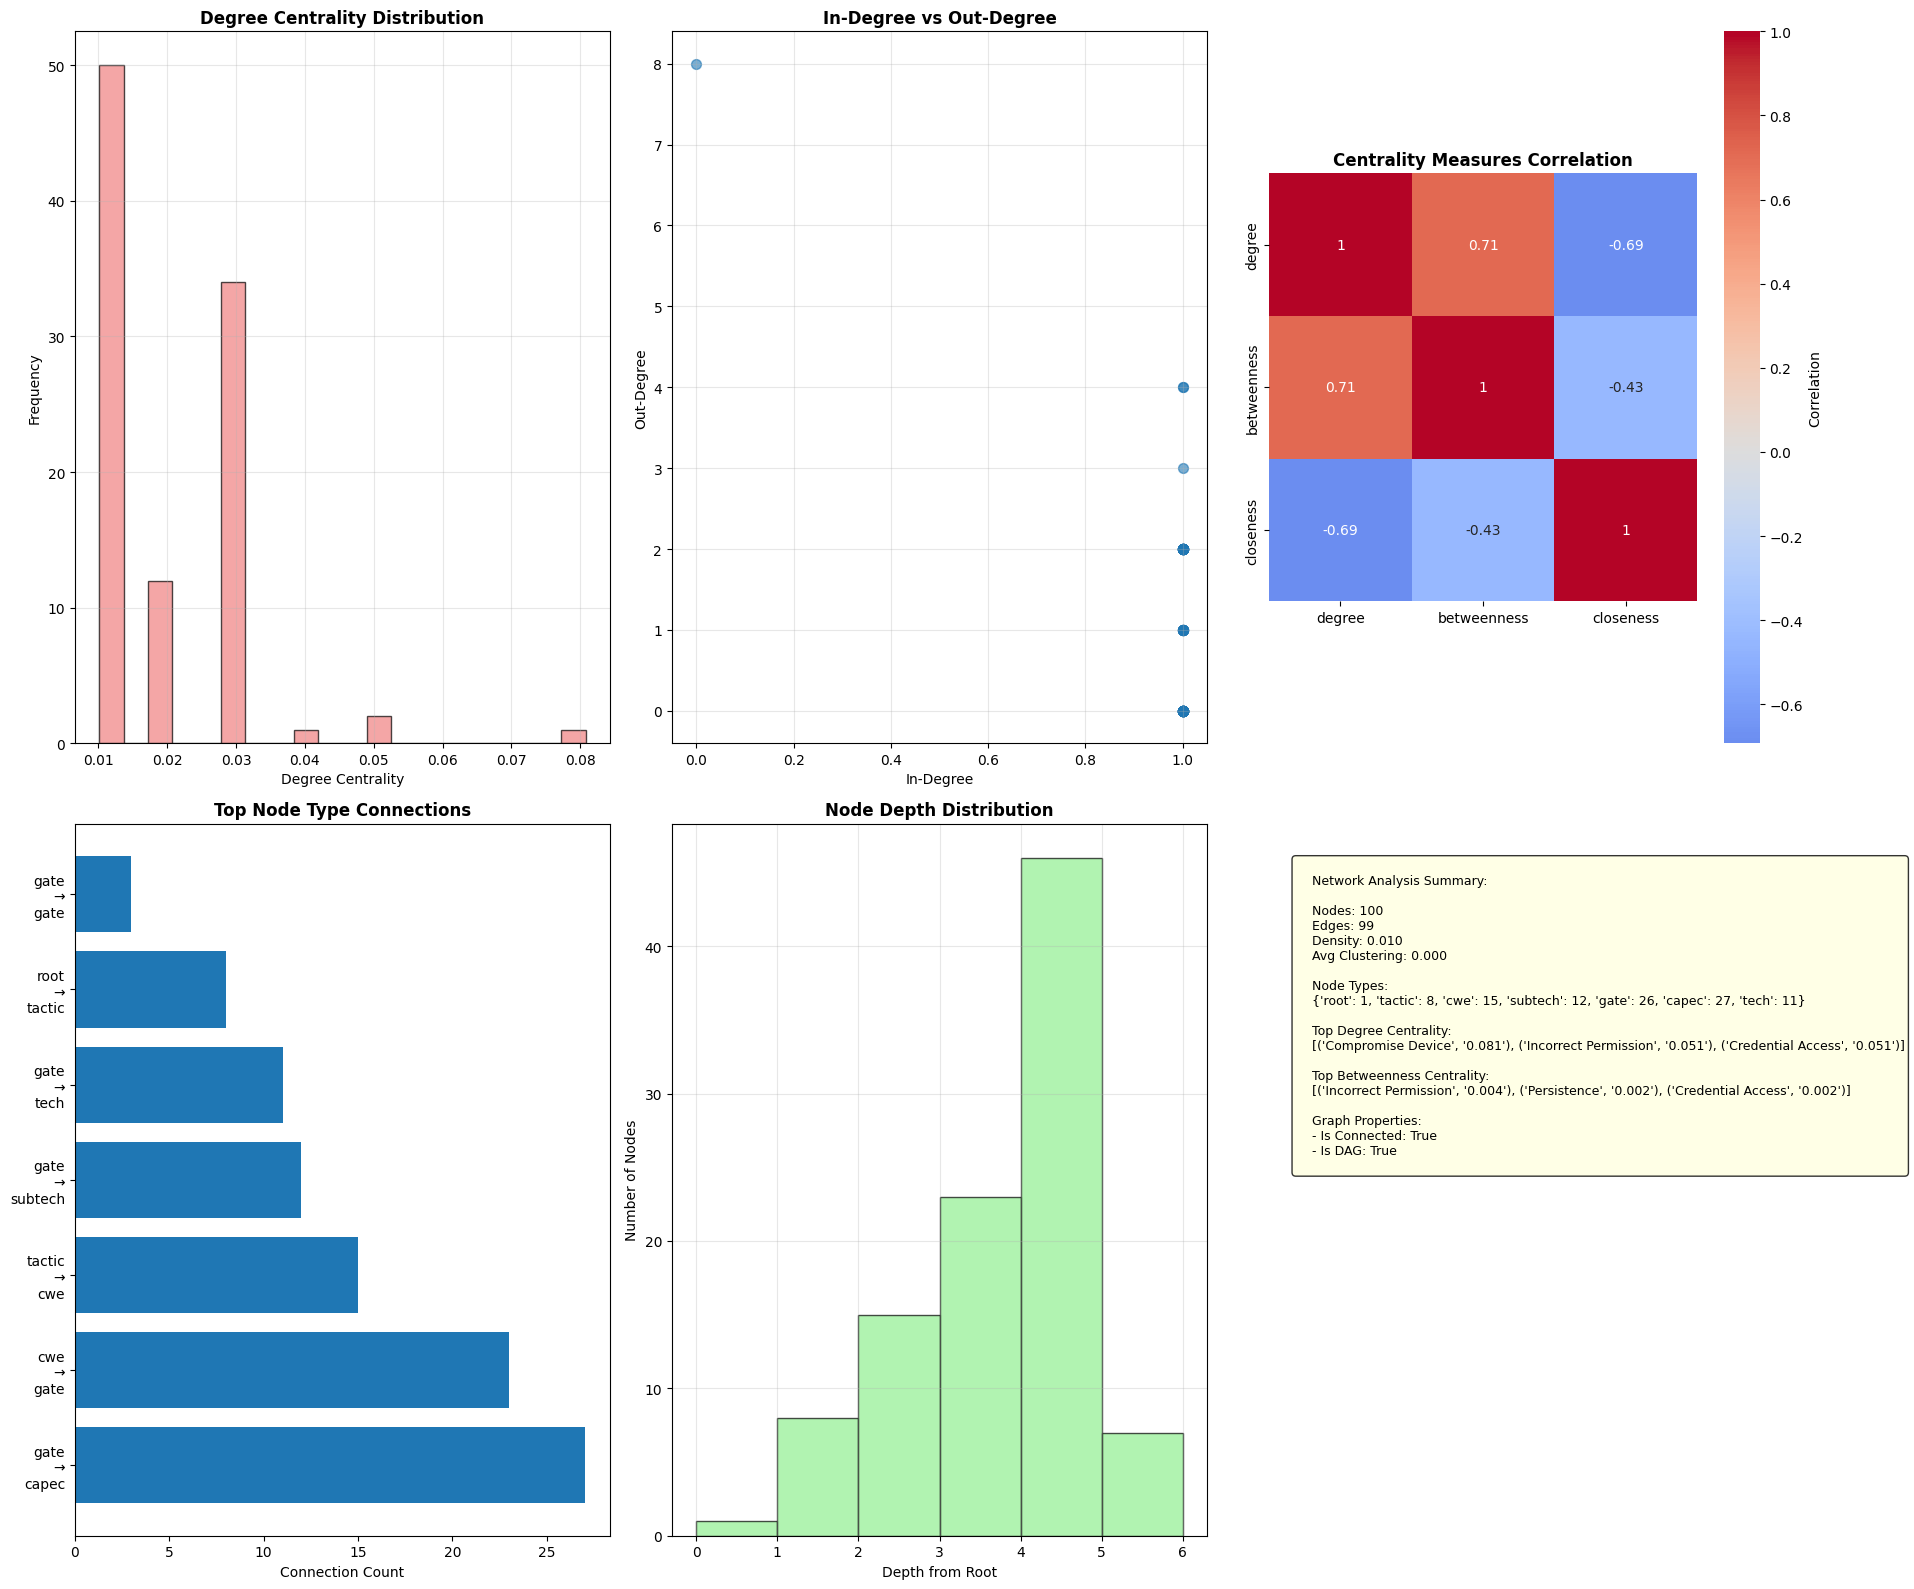

In [ ]:
# Visualization 5: Network Graph Analysis
def create_network_analysis():
    # Create network graph
    G = nx.DiGraph()
    
    # Add nodes with attributes
    for node_id, node in data['nodes'].items():
        G.add_node(node_id, 
                  label=node['label'],
                  node_type=node['node_type'],
                  tactic=node.get('tactic_context', 'None'))
    
    # Add edges from adjacency list
    for source, targets in data['adjacency_list'].items():
        for target in targets:
            G.add_edge(source, target)
    
    plt.figure(figsize=(20, 16))
    
    # Network structure analysis
    plt.subplot(2, 3, 1)
    
    # Calculate centrality measures
    degree_centrality = nx.degree_centrality(G)
    betweenness_centrality = nx.betweenness_centrality(G)
    closeness_centrality = nx.closeness_centrality(G)
    
    # Plot degree centrality distribution
    plt.hist(list(degree_centrality.values()), bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
    plt.xlabel('Degree Centrality')
    plt.ylabel('Frequency')
    plt.title('Degree Centrality Distribution', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Network metrics
    plt.subplot(2, 3, 2)
    
    # In-degree and out-degree analysis
    in_degrees = [G.in_degree(n) for n in G.nodes()]
    out_degrees = [G.out_degree(n) for n in G.nodes()]
    
    plt.scatter(in_degrees, out_degrees, alpha=0.6, s=50)
    plt.xlabel('In-Degree')
    plt.ylabel('Out-Degree')
    plt.title('In-Degree vs Out-Degree', fontsize=12, fontweight='bold')
    plt.grid(True, alpha=0.3)
    
    # Add node type colors
    node_colors = []
    node_type_color_map = {
        'root': 'red', 'tactic': 'blue', 'cwe': 'green', 
        'tech': 'orange', 'subtech': 'purple', 'capec': 'brown', 'gate': 'gray'
    }
    
    for node in G.nodes():
        node_type = data['nodes'][node]['node_type']
        node_colors.append(node_type_color_map.get(node_type, 'black'))
    
    # Centrality comparison
    plt.subplot(2, 3, 3)
    centrality_df = pd.DataFrame({
        'degree': list(degree_centrality.values()),
        'betweenness': list(betweenness_centrality.values()),
        'closeness': list(closeness_centrality.values())
    })
    
    correlation_matrix = centrality_df.corr()
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, cbar_kws={'label': 'Correlation'})
    plt.title('Centrality Measures Correlation', fontsize=12, fontweight='bold')
    
    # Node type connectivity
    plt.subplot(2, 3, 4)
    node_type_connections = defaultdict(int)
    
    for edge in G.edges():
        source_type = data['nodes'][edge[0]]['node_type']
        target_type = data['nodes'][edge[1]]['node_type']
        connection_type = f"{source_type} -> {target_type}"
        node_type_connections[connection_type] += 1
    
    # Show top connections
    top_connections = dict(Counter(node_type_connections).most_common(10))
    y_pos = np.arange(len(top_connections))
    plt.barh(y_pos, list(top_connections.values()))
    plt.yticks(y_pos, [conn.replace(' -> ', '\n→\n') for conn in top_connections.keys()])
    plt.xlabel('Connection Count')
    plt.title('Top Node Type Connections', fontsize=12, fontweight='bold')
    
    # Path depth analysis
    plt.subplot(2, 3, 5)
    
    # Calculate shortest paths from root
    root_node = 'root_0'
    if root_node in G:
        try:
            shortest_paths = nx.single_source_shortest_path_length(G, root_node)
            depths = list(shortest_paths.values())
            
            plt.hist(depths, bins=range(min(depths), max(depths)+2), 
                     alpha=0.7, color='lightgreen', edgecolor='black')
            plt.xlabel('Depth from Root')
            plt.ylabel('Number of Nodes')
            plt.title('Node Depth Distribution', fontsize=12, fontweight='bold')
            plt.grid(True, alpha=0.3)
        except:
            plt.text(0.5, 0.5, 'Graph connectivity\nissue detected', 
                    ha='center', va='center', transform=plt.gca().transAxes)
            plt.title('Node Depth Distribution', fontsize=12, fontweight='bold')
    
    # Network statistics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    # Calculate additional metrics
    try:
        avg_clustering = nx.average_clustering(G.to_undirected())
    except:
        avg_clustering = 0
    
    try:
        density = nx.density(G)
    except:
        density = 0
    
    # Top nodes by centrality
    top_degree_nodes = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:3]
    top_betweenness_nodes = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:3]
    
    network_stats = f"""
    Network Analysis Summary:
    
    Nodes: {G.number_of_nodes()}
    Edges: {G.number_of_edges()}
    Density: {density:.3f}
    Avg Clustering: {avg_clustering:.3f}
    
    Node Types:
    {dict(Counter([data['nodes'][n]['node_type'] for n in G.nodes()]))}
    
    Top Degree Centrality:
    {[(data['nodes'][node]['label'][:20], f'{score:.3f}') for node, score in top_degree_nodes]}
    
    Top Betweenness Centrality:
    {[(data['nodes'][node]['label'][:20], f'{score:.3f}') for node, score in top_betweenness_nodes]}
    
    Graph Properties:
    - Is Connected: {nx.is_weakly_connected(G)}
    - Is DAG: {nx.is_directed_acyclic_graph(G)}
    """
    
    plt.text(0.05, 0.95, network_stats, fontsize=9, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('network_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return G, degree_centrality, betweenness_centrality

G, degree_centrality, betweenness_centrality = create_network_analysis()

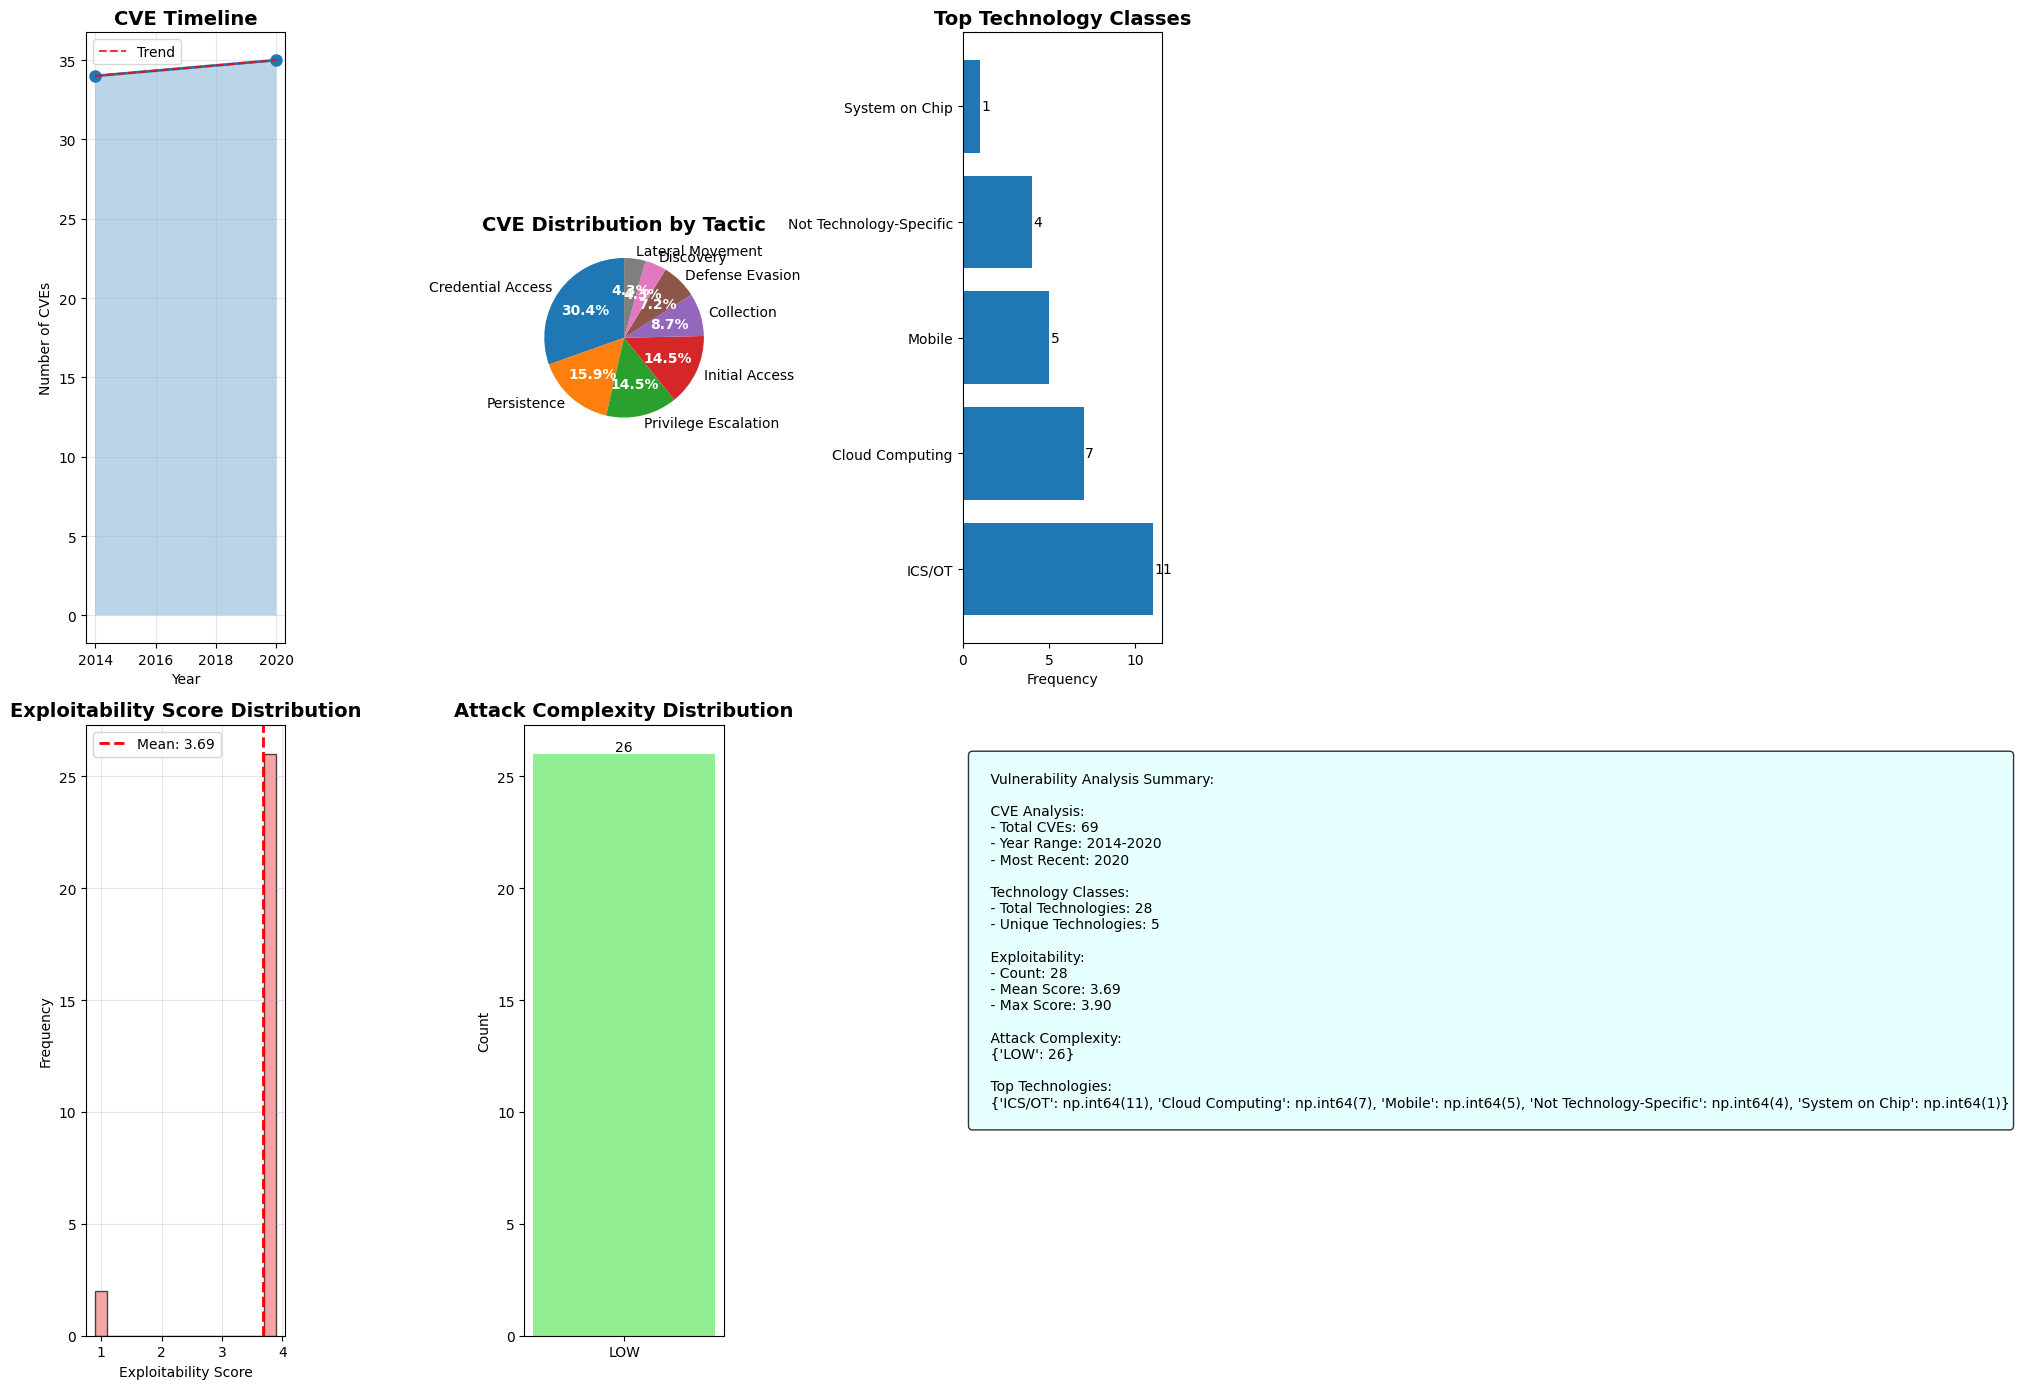

In [ ]:
# Visualization 6: CVE Timeline and Technology Analysis
def create_cve_timeline_analysis():
    # Extract CVE information
    cve_data = []
    technology_data = []
    
    for node_id, node in data['nodes'].items():
        if 'CVE ID' in node['metadata']:
            cve_ids = node['metadata']['CVE ID']
            if '|' in str(cve_ids):
                cves = str(cve_ids).split(' | ')
            else:
                cves = [str(cve_ids)]
            
            for cve in cves:
                cve = cve.strip()
                if cve.startswith('CVE-'):
                    try:
                        year = int(cve.split('-')[1])
                        cve_data.append({
                            'cve': cve,
                            'year': year,
                            'node_type': node['node_type'],
                            'tactic': node.get('tactic_context', 'Unknown')
                        })
                    except:
                        pass
        
        if 'cwe_Technology_Class' in node['metadata']:
            tech_classes = node['metadata']['cwe_Technology_Class']
            if ',' in str(tech_classes):
                techs = [t.strip() for t in str(tech_classes).split(',')]
            else:
                techs = [str(tech_classes)]
            
            for tech in techs:
                if tech not in ['', 'N/A', 'None']:
                    technology_data.append({
                        'technology': tech,
                        'node_type': node['node_type'],
                        'tactic': node.get('tactic_context', 'Unknown')
                    })
    
    cve_df = pd.DataFrame(cve_data)
    tech_df = pd.DataFrame(technology_data)
    
    plt.figure(figsize=(18, 14))
    
    # CVE timeline
    if not cve_df.empty:
        plt.subplot(2, 3, 1)
        cve_year_counts = cve_df['year'].value_counts().sort_index()
        
        plt.plot(cve_year_counts.index, cve_year_counts.values, marker='o', linewidth=2, markersize=8)
        plt.fill_between(cve_year_counts.index, cve_year_counts.values, alpha=0.3)
        plt.xlabel('Year')
        plt.ylabel('Number of CVEs')
        plt.title('CVE Timeline', fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        
        # Add trend line
        z = np.polyfit(cve_year_counts.index, cve_year_counts.values, 1)
        p = np.poly1d(z)
        plt.plot(cve_year_counts.index, p(cve_year_counts.index), "--", alpha=0.8, color='red', label='Trend')
        plt.legend()
        
        # CVE distribution by tactic
        plt.subplot(2, 3, 2)
        cve_tactic_counts = cve_df['tactic'].value_counts()
        
        wedges, texts, autotexts = plt.pie(cve_tactic_counts.values, labels=cve_tactic_counts.index, 
                                          autopct='%1.1f%%', startangle=90)
        plt.title('CVE Distribution by Tactic', fontsize=14, fontweight='bold')
        
        # Make text more readable
        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontweight('bold')
    
    # Technology class analysis
    if not tech_df.empty:
        plt.subplot(2, 3, 3)
        tech_counts = tech_df['technology'].value_counts()
        
        # Show top 10 technologies
        top_tech = tech_counts.head(10)
        bars = plt.barh(range(len(top_tech)), top_tech.values)
        plt.yticks(range(len(top_tech)), top_tech.index)
        plt.xlabel('Frequency')
        plt.title('Top Technology Classes', fontsize=14, fontweight='bold')
        
        # Add value labels
        for i, (bar, value) in enumerate(zip(bars, top_tech.values)):
            plt.text(value + 0.1, i, str(value), va='center')
    
    # Exploitability analysis
    plt.subplot(2, 3, 4)
    exploitability_scores = []
    
    for node_id, node in data['nodes'].items():
        if 'exploitabilityScore' in node['metadata']:
            scores = node['metadata']['exploitabilityScore']
            if '|' in str(scores):
                for score in str(scores).split(' | '):
                    try:
                        exploitability_scores.append(float(score))
                    except:
                        pass
            else:
                try:
                    exploitability_scores.append(float(scores))
                except:
                    pass
    
    if exploitability_scores:
        plt.hist(exploitability_scores, bins=15, alpha=0.7, color='lightcoral', edgecolor='black')
        plt.axvline(np.mean(exploitability_scores), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {np.mean(exploitability_scores):.2f}')
        plt.xlabel('Exploitability Score')
        plt.ylabel('Frequency')
        plt.title('Exploitability Score Distribution', fontsize=14, fontweight='bold')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    # Attack complexity analysis
    plt.subplot(2, 3, 5)
    attack_complexity = []
    
    for node_id, node in data['nodes'].items():
        if 'attackComplexity' in node['metadata']:
            complexity = node['metadata']['attackComplexity']
            if complexity not in ['', 'N/A', 'None']:
                attack_complexity.append(str(complexity))
    
    if attack_complexity:
        complexity_counts = Counter(attack_complexity)
        colors = ['lightgreen' if c == 'LOW' else 'orange' if c == 'MEDIUM' else 'red' 
                 for c in complexity_counts.keys()]
        
        bars = plt.bar(complexity_counts.keys(), complexity_counts.values(), color=colors)
        plt.ylabel('Count')
        plt.title('Attack Complexity Distribution', fontsize=14, fontweight='bold')
        
        for bar in bars:
            height = bar.get_height()
            plt.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}', ha='center', va='bottom')
    
    # Summary statistics
    plt.subplot(2, 3, 6)
    plt.axis('off')
    
    summary_text = f"""
    Vulnerability Analysis Summary:
    
    CVE Analysis:
    - Total CVEs: {len(cve_df) if not cve_df.empty else 0}
    - Year Range: {f"{cve_df['year'].min()}-{cve_df['year'].max()}" if not cve_df.empty else "N/A"}
    - Most Recent: {cve_df['year'].max() if not cve_df.empty else "N/A"}
    
    Technology Classes:
    - Total Technologies: {len(tech_df) if not tech_df.empty else 0}
    - Unique Technologies: {tech_df['technology'].nunique() if not tech_df.empty else 0}
    
    Exploitability:
    - Count: {len(exploitability_scores)}
    - Mean Score: {f"{np.mean(exploitability_scores):.2f}" if exploitability_scores else "N/A"}
    - Max Score: {f"{np.max(exploitability_scores):.2f}" if exploitability_scores else "N/A"}
    
    Attack Complexity:
    {dict(Counter(attack_complexity)) if attack_complexity else "No data"}
    
    Top Technologies:
    {dict(tech_counts.head(5)) if not tech_df.empty else "No data"}
    """
    
    plt.text(0.05, 0.95, summary_text, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='lightcyan', alpha=0.8))
    
    plt.tight_layout()
    plt.savefig('cve_timeline_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return cve_df, tech_df, exploitability_scores

cve_df, tech_df, exploitability_scores = create_cve_timeline_analysis()